## this notebook make eda with data and create baseline with RandomForest

In [1]:
!hf download ivkrotova/rupaws_dataset --local-dir ./../data/rupaws

Hint: A new version of huggingface_hub (1.17.0) is available! You are using version 1.16.1.
Error: Model 'ivkrotova/rupaws_dataset' not found. If the repo is private, make sure you are authenticated and your token has the required permissions.
Set HF_DEBUG=1 as environment variable for full traceback.


In [2]:
!uv add seaborn

Resolved 169 packages in 13ms
Audited 147 packages in 31ms


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, accuracy_score

In [4]:
df_train = pd.read_csv("../data/train/rupaws_qqp_train.csv", sep=";")

In [5]:
df_train_wiki = pd.read_csv("../data/train/rupaws_wiki_train.csv", sep=';')

In [6]:
df_train_wiki.head()

,Unnamed: 0,sentence1,sentence2,label
0,1872,От автобусной остановки автобусы следуют до го...,"Автобусы идут от автовокзала в Бейлдон, Брэфсб...",0
1,308,"Стюартстоун расположен на севере, Диксвилль на...","К северу находится Стюартстоун, к востоку - Ко...",0
2,2434,"Он играл за клуб ""Kansas City Royals"" в течени...",Он сыграл за Chicago Cubs в течение десяти мат...,0
3,1290,"""Энкор"" слился с ""Сибирскими авиалиниями"" в 20...","В 2001 году авиакомпания ""Сибирь"" объединилась...",0
4,3159,В апреле 2014 президент Кеннет Свендсен ушел в...,Президент Кеннет Свендсен ушел в отставку в ап...,1


In [7]:
df_train.head()

,sentence1,sentence2,label
0,"Почему же такие богатые мусульманские страны, ...","Почему богатые мусульманские страны, такие как...",1
1,Что представляет собой государственно-частное ...,Что представляет собой государственно-частное ...,1
2,В чем различия между объектно-ориентированным ...,В чем различия между объектно-ориентированным ...,1
3,"Являются ли современные языки (т.е. латынь, др...","Являются ли древние языки (т.е. латынь, древне...",0
4,"Если вы можете любить кого-то, но не любить их...","Если вы можете любить кого-то, но не любить их...",1


In [8]:
df_train_wiki.columns.to_list()

['Unnamed: 0', 'sentence1', 'sentence2', 'label']

In [9]:
df_train_wiki = df_train_wiki.drop(columns=['Unnamed: 0'])

In [10]:
df_train_wiki.head()

,sentence1,sentence2,label
0,От автобусной остановки автобусы следуют до го...,"Автобусы идут от автовокзала в Бейлдон, Брэфсб...",0
1,"Стюартстоун расположен на севере, Диксвилль на...","К северу находится Стюартстоун, к востоку - Ко...",0
2,"Он играл за клуб ""Kansas City Royals"" в течени...",Он сыграл за Chicago Cubs в течение десяти мат...,0
3,"""Энкор"" слился с ""Сибирскими авиалиниями"" в 20...","В 2001 году авиакомпания ""Сибирь"" объединилась...",0
4,В апреле 2014 президент Кеннет Свендсен ушел в...,Президент Кеннет Свендсен ушел в отставку в ап...,1


In [11]:
df_train = pd.concat([df_train, df_train_wiki], ignore_index=True)

In [12]:
df_train.head()

,sentence1,sentence2,label
0,"Почему же такие богатые мусульманские страны, ...","Почему богатые мусульманские страны, такие как...",1
1,Что представляет собой государственно-частное ...,Что представляет собой государственно-частное ...,1
2,В чем различия между объектно-ориентированным ...,В чем различия между объектно-ориентированным ...,1
3,"Являются ли современные языки (т.е. латынь, др...","Являются ли древние языки (т.е. латынь, древне...",0
4,"Если вы можете любить кого-то, но не любить их...","Если вы можете любить кого-то, но не любить их...",1


In [13]:
len(df_train)

7596

In [14]:
dl = df_train['label'].value_counts()

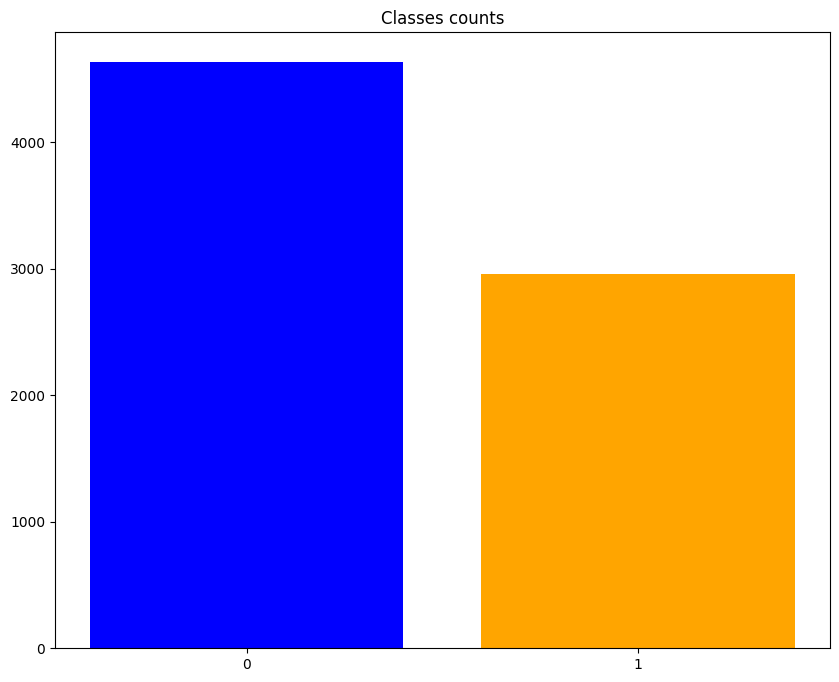

In [15]:
plt.figure(figsize=(10, 8))
plt.bar(['0', '1'], [dl[0], dl[1]], color=['blue', 'orange'])
plt.title("Classes counts")
plt.grid(False)
plt.savefig('../artifacts/distribution_counts_classes.png')
plt.show()

In [16]:
df_train['len_1'] = (df_train['sentence1']).str.len()
df_train['len_2'] = (df_train['sentence2']).str.len()
df_train.head()

,sentence1,sentence2,label,len_1,len_2
0,"Почему же такие богатые мусульманские страны, ...","Почему богатые мусульманские страны, такие как...",1,169,168
1,Что представляет собой государственно-частное ...,Что представляет собой государственно-частное ...,1,64,64
2,В чем различия между объектно-ориентированным ...,В чем различия между объектно-ориентированным ...,1,91,91
3,"Являются ли современные языки (т.е. латынь, др...","Являются ли древние языки (т.е. латынь, древне...",0,155,156
4,"Если вы можете любить кого-то, но не любить их...","Если вы можете любить кого-то, но не любить их...",1,93,93


In [17]:
df_train[['len_1', 'len_2']].value_counts()

len_1  len_2
73     73       24
62     62       22
65     65       21
95     95       19
99     99       19
                ..
       79        1
127    160       1
140    113       1
127    144       1
119    115       1
Name: count, Length: 3787, dtype: int64

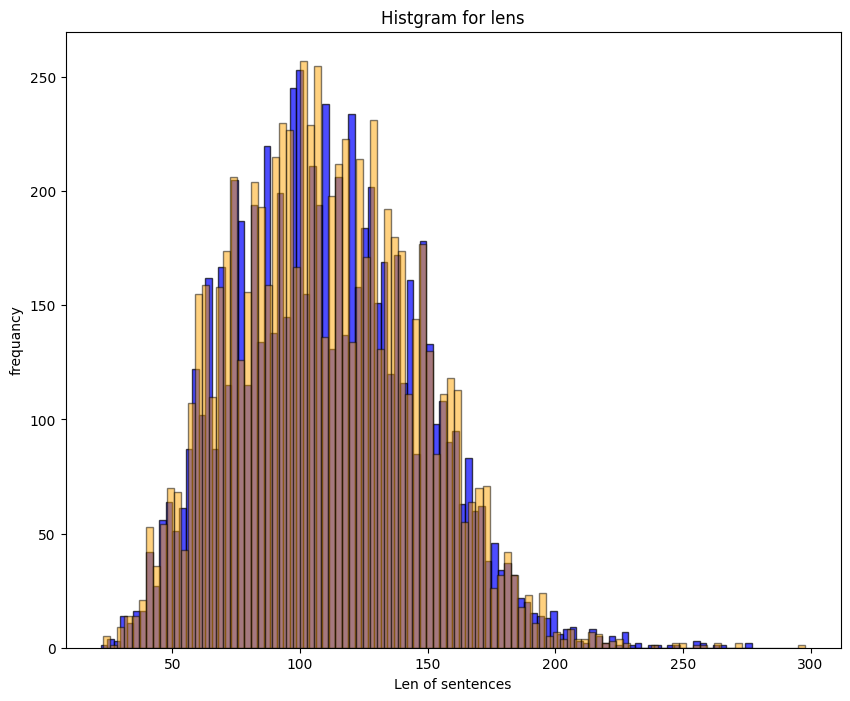

In [18]:
plt.figure(figsize=(10, 8))
plt.hist(df_train['len_1'], bins=100, color='blue', edgecolor='black', alpha=0.7)
plt.hist(df_train['len_2'], bins=100, color='orange', edgecolor='black', alpha=0.5)
plt.xlabel("Len of sentences")
plt.ylabel("frequancy")
plt.title("Histgram for lens")
plt.savefig("../artifacts/histagram_of_lens.png")
plt.show()

In [19]:
df_train[df_train['label'] == 0]['len_1'].mean()

np.float64(112.05929279862009)

In [20]:
df_train[df_train['label'] == 1]['len_1'].mean()

np.float64(108.44523326572008)

In [21]:
def counts_similar_words(string1, string2):
    counts = 0
    for s in string1.split():
        if s in string2:
            counts += 1
            
    return counts

df_train['similar_words'] = df_train.apply(lambda row: counts_similar_words(row['sentence1'], row['sentence2']), axis=1)

In [22]:
df_train['similar_words']

0       18
1        6
2        9
3       18
4       18
        ..
7591     9
7592    16
7593    13
7594    14
7595    13
Name: similar_words, Length: 7596, dtype: int64

In [23]:
df_train[df_train['label'] == 1]['similar_words']

0       18
1        6
2        9
4       18
5        9
        ..
7579    13
7584    10
7591     9
7593    13
7595    13
Name: similar_words, Length: 2958, dtype: int64

In [24]:
df_train['ratio_len'] = df_train['len_1'] / df_train['len_2']

In [25]:
def counts_similar_symbols(str1, str2):
    counts = 0
    for s in str1:
        if s in str2:
            counts += 1
            
    return counts

df_train['similar_symbols'] = df_train.apply(lambda row: counts_similar_symbols(row['sentence1'], row['sentence2']), axis=1)

In [26]:
def unique_words(str1, str2):
    counts = 0
    for s in str1.split():
        if s not in str2:
            counts += 1
            
    return counts

df_train['unique_1'] = df_train.apply(lambda row: unique_words(row['sentence1'], row['sentence2']), axis=1)
df_train['unique_2'] = df_train.apply(lambda row: unique_words(row['sentence2'], row['sentence1']), axis=1)

In [27]:
def jaccard(str1, str2):
    set1 = set(str1.split())
    set2 = set(str2.split())
    intersection = len(set1 & set2)
    union = len(set1 | set2)
    return intersection / union if union > 0 else 0
df_train['jaccard'] = df_train.apply(lambda row: jaccard(row['sentence1'], row['sentence2']), axis=1)

In [28]:
df_train['common_start'] = df_train.apply(lambda row: row['sentence1'].split()[0] == row['sentence2'].split()[0], axis=1)
df_train['common_end'] = df_train.apply(lambda row: row['sentence1'].split()[-1] == row['sentence2'].split()[-1], axis=1)

In [29]:
df_train['diff_len'] = df_train['len_1'] - df_train['len_2']

In [30]:
df_train.head()

,sentence1,sentence2,label,len_1,len_2,similar_words,ratio_len,similar_symbols,unique_1,unique_2,jaccard,common_start,common_end,diff_len
0,"Почему же такие богатые мусульманские страны, ...","Почему богатые мусульманские страны, такие как...",1,169,168,18,1.005952,169,3,3,0.666667,True,True,1
1,Что представляет собой государственно-частное ...,Что представляет собой государственно-частное ...,1,64,64,6,1.000000,64,0,0,1.000000,True,True,0
2,В чем различия между объектно-ориентированным ...,В чем различия между объектно-ориентированным ...,1,91,91,9,1.000000,91,0,0,1.000000,True,True,0
3,"Являются ли современные языки (т.е. латынь, др...","Являются ли древние языки (т.е. латынь, древне...",0,155,156,18,0.993590,155,1,1,0.900000,True,True,-1
4,"Если вы можете любить кого-то, но не любить их...","Если вы можете любить кого-то, но не любить их...",1,93,93,18,1.000000,93,0,0,1.000000,True,True,0


In [31]:
df_train = df_train.drop(columns=['sentence1', 'sentence2'])

In [32]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 7596 entries, 0 to 7595
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   label            7596 non-null   int64  
 1   len_1            7596 non-null   int64  
 2   len_2            7596 non-null   int64  
 3   similar_words    7596 non-null   int64  
 4   ratio_len        7596 non-null   float64
 5   similar_symbols  7596 non-null   int64  
 6   unique_1         7596 non-null   int64  
 7   unique_2         7596 non-null   int64  
 8   jaccard          7596 non-null   float64
 9   common_start     7596 non-null   bool   
 10  common_end       7596 non-null   bool   
 11  diff_len         7596 non-null   int64  
dtypes: bool(2), float64(2), int64(8)
memory usage: 608.4 KB


In [33]:
Y = df_train['label']
X = df_train.drop(columns=['label'])

In [34]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

In [35]:
param_grid = {
    "n_estimators": [100, 200, 300, 400],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    "class_weight": [None, 'balanced']
}

rf_base = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    rf_base,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, Y_train)

print('The best parameters: ', grid_search.best_params_)
print("The best F1 on cv: ", grid_search.best_score_)

The best parameters:  {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 300}
The best F1 on cv:  0.5258456143219715


In [36]:
rf = grid_search.best_estimator_

In [37]:
y_pred = rf.predict(X_test)

In [38]:
print(f'Precision: {precision_score(Y_test, y_pred)}')
print(f'Accuracy: {accuracy_score(Y_test, y_pred)}')
print(f'Recall: {recall_score(Y_test, y_pred)}')
print(f'F1-score {f1_score(Y_test, y_pred)}')
print('\n\n')
print(classification_report(Y_test, y_pred))

Precision: 0.5785876993166287
Accuracy: 0.655921052631579
Recall: 0.42905405405405406
F1-score 0.492725509214355



              precision    recall  f1-score   support

           0       0.69      0.80      0.74       928
           1       0.58      0.43      0.49       592

    accuracy                           0.66      1520
   macro avg       0.63      0.61      0.62      1520
weighted avg       0.64      0.66      0.64      1520



In [39]:
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(importance)

            feature  importance
7           jaccard    0.193826
6          unique_2    0.102932
5          unique_1    0.101147
3         ratio_len    0.099422
1             len_2    0.095954
4   similar_symbols    0.090320
0             len_1    0.087903
2     similar_words    0.073891
10         diff_len    0.071571
9        common_end    0.067777
8      common_start    0.015258
